# Titanic Survival Analysis


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Load Dataset

In [6]:
df=pd.read_csv('/Users/amankumar/Desktop/DataSet_project/Titanic/train_and_test2.csv')

### Data Exploration

In [9]:
df.head()

,Passengerid,Age,Fare,Sex,sibsp,zero,zero.1,zero.2,zero.3,zero.4,...,zero.12,zero.13,zero.14,Pclass,zero.15,zero.16,Embarked,zero.17,zero.18,2urvived
0,1,22.0,7.2500,0,1,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0
1,2,38.0,71.2833,1,1,0,0,0,0,0,...,0,0,0,1,0,0,0.0,0,0,1
2,3,26.0,7.9250,1,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,1
3,4,35.0,53.1000,1,1,0,0,0,0,0,...,0,0,0,1,0,0,2.0,0,0,1
4,5,35.0,8.0500,0,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0


In [13]:
# Check the number of rows and columns
df.shape

(1309, 28)

In [15]:
# Check dataset information and data types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 28 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Passengerid  1309 non-null   int64  
 1   Age          1309 non-null   float64
 2   Fare         1309 non-null   float64
 3   Sex          1309 non-null   int64  
 4   sibsp        1309 non-null   int64  
 5   zero         1309 non-null   int64  
 6   zero.1       1309 non-null   int64  
 7   zero.2       1309 non-null   int64  
 8   zero.3       1309 non-null   int64  
 9   zero.4       1309 non-null   int64  
 10  zero.5       1309 non-null   int64  
 11  zero.6       1309 non-null   int64  
 12  Parch        1309 non-null   int64  
 13  zero.7       1309 non-null   int64  
 14  zero.8       1309 non-null   int64  
 15  zero.9       1309 non-null   int64  
 16  zero.10      1309 non-null   int64  
 17  zero.11      1309 non-null   int64  
 18  zero.12      1309 non-null   int64  
 19  zero.13      1309

In [17]:
# Check missing values in each column
df.isnull().sum()

Passengerid    0
Age            0
Fare           0
Sex            0
sibsp          0
zero           0
zero.1         0
zero.2         0
zero.3         0
zero.4         0
zero.5         0
zero.6         0
Parch          0
zero.7         0
zero.8         0
zero.9         0
zero.10        0
zero.11        0
zero.12        0
zero.13        0
zero.14        0
Pclass         0
zero.15        0
zero.16        0
Embarked       2
zero.17        0
zero.18        0
2urvived       0
dtype: int64

In [18]:
# Display the statistical summary of numerical columns
df.describe()

,Passengerid,Age,Fare,Sex,sibsp,zero,zero.1,zero.2,zero.3,zero.4,...,zero.12,zero.13,zero.14,Pclass,zero.15,zero.16,Embarked,zero.17,zero.18,2urvived
count,1309.000000,1309.000000,1309.000000,1309.000000,1309.000000,1309.0,1309.0,1309.0,1309.0,1309.0,...,1309.0,1309.0,1309.0,1309.000000,1309.0,1309.0,1307.000000,1309.0,1309.0,1309.000000
mean,655.000000,29.503186,33.281086,0.355997,0.498854,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,2.294882,0.0,0.0,1.492731,0.0,0.0,0.261268
std,378.020061,12.905241,51.741500,0.478997,1.041658,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.837836,0.0,0.0,0.814626,0.0,0.0,0.439494
min,1.000000,0.170000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.000000,0.0,0.0,0.000000,0.0,0.0,0.000000
25%,328.000000,22.000000,7.895800,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,2.000000,0.0,0.0,1.000000,0.0,0.0,0.000000
50%,655.000000,28.000000,14.454200,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,3.000000,0.0,0.0,2.000000,0.0,0.0,0.000000
75%,982.000000,35.000000,31.275000,1.000000,1.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,3.000000,0.0,0.0,2.000000,0.0,0.0,1.000000
max,1309.000000,80.000000,512.329200,1.000000,8.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,3.000000,0.0,0.0,2.000000,0.0,0.0,1.000000


###  Data Cleaning

In [25]:
# Check for duplicate rows
df.duplicated().sum()

np.int64(0)

In [28]:
# Fill missing values in the Age column using the median
df['Age'].fillna(df['Age'].median())

0       22.0
1       38.0
2       26.0
3       35.0
4       35.0
        ... 
1304    28.0
1305    39.0
1306    38.5
1307    28.0
1308    28.0
Name: Age, Length: 1309, dtype: float64

In [31]:
# Fill missing values in the Embarked column using the mode
df.fillna(df['Embarked'].mode()[0],inplace=True)

,Passengerid,Age,Fare,Sex,sibsp,zero,zero.1,zero.2,zero.3,zero.4,...,zero.12,zero.13,zero.14,Pclass,zero.15,zero.16,Embarked,zero.17,zero.18,2urvived
0,1,22.0,7.2500,0,1,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0
1,2,38.0,71.2833,1,1,0,0,0,0,0,...,0,0,0,1,0,0,0.0,0,0,1
2,3,26.0,7.9250,1,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,1
3,4,35.0,53.1000,1,1,0,0,0,0,0,...,0,0,0,1,0,0,2.0,0,0,1
4,5,35.0,8.0500,0,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,1305,28.0,8.0500,0,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0
1305,1306,39.0,108.9000,1,0,0,0,0,0,0,...,0,0,0,1,0,0,0.0,0,0,0
1306,1307,38.5,7.2500,0,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0
1307,1308,28.0,8.0500,0,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0


In [41]:
# Drop the Cabin column
df.drop(['zero','zero.1','zero.2','zero.3'],axis=1,inplace=True)

In [43]:
# Check missing values after cleaning
df.isnull().sum()

Passengerid    0
Age            0
Fare           0
Sex            0
sibsp          0
zero.4         0
zero.5         0
zero.6         0
Parch          0
zero.7         0
zero.8         0
zero.9         0
zero.10        0
zero.11        0
zero.12        0
zero.13        0
zero.14        0
Pclass         0
zero.15        0
zero.16        0
Embarked       0
zero.17        0
zero.18        0
2urvived       0
dtype: int64

In [48]:
# Calculate the survival rate by gender
df.rename(columns={'2urvived': 'Survived'}, inplace=True)
df.groupby('Sex')['Survived'].mean()

Sex
0    0.1293
1    0.5000
Name: Survived, dtype: float64

In [49]:
# Calculate the survival rate by passenger class
df.groupby('Pclass')['Survived'].mean()

Pclass
1    0.421053
2    0.314079
3    0.167842
Name: Survived, dtype: float64

In [51]:
# Calculate the survival rate by gender and passenger class
df.groupby(['Sex','Pclass'])['Survived'].mean()

Sex  Pclass
0    1         0.251397
     2         0.099415
     3         0.095335
1    1         0.631944
     2         0.660377
     3         0.333333
Name: Survived, dtype: float64

In [52]:
# Create a pivot table to compare survival rates by gender and passenger class
df.pivot_table(
    values='Survived',
    index='Sex',
    columns='Pclass',
    aggfunc='mean'
)

Pclass,1,2,3
Sex,,,
0,0.251397,0.099415,0.095335
1,0.631944,0.660377,0.333333


### Calculations & Conditions

In [58]:
# Calculate the average age of passengers
df['Age'].mean()

np.float64(29.50318563789152)

In [59]:
# Calculate the total number of survived passengers
df['Survived'].sum()

np.int64(342)

In [60]:
# Calculate the overall survival rate
df['Survived'].mean()

np.float64(0.2612681436210848)

In [69]:
# Create age groups based on passenger age: Child, Adult, and Senior
df['AgeGroup']=pd.cut(
    df['Age'],
    bins=[10,18,60,100],
    labels=['Child','Adult','Senior']
)
df['AgeGroup'].sample(10)

990     Adult
563     Adult
128     Adult
966     Adult
129     Adult
987    Senior
473     Adult
901     Adult
282     Child
753     Adult
Name: AgeGroup, dtype: category
Categories (3, str): ['Child' < 'Adult' < 'Senior']

In [71]:
# Calculate the correlation between Age and Survived
df['Age'].corr(df['Survived'])

np.float64(-0.055861645693167664)

## Basic Visualization

<Axes: xlabel='Survived'>

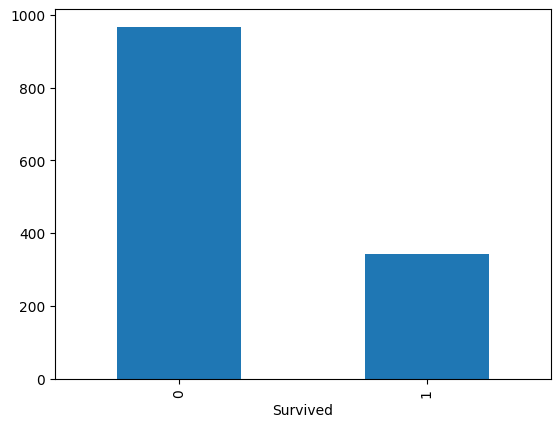

In [72]:
# Create a bar chart showing survived and non-survived passengers
df['Survived'].value_counts().plot(kind='bar')

<Axes: ylabel='Frequency'>

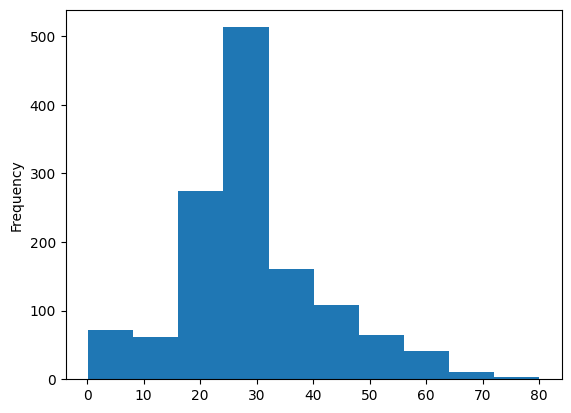

In [75]:
# Create a histogram showing the age distribution of passengers
df['Age'].plot(kind='hist')

<Axes: xlabel='Sex'>

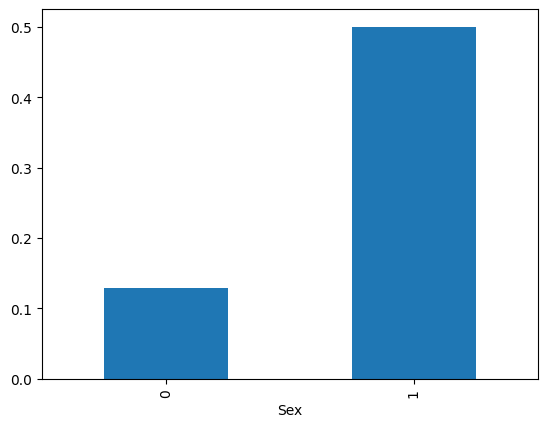

In [78]:
# Create a bar chart comparing survival rates by gender
df.groupby('Sex')['Survived'].mean().plot(kind='bar')

<Axes: >

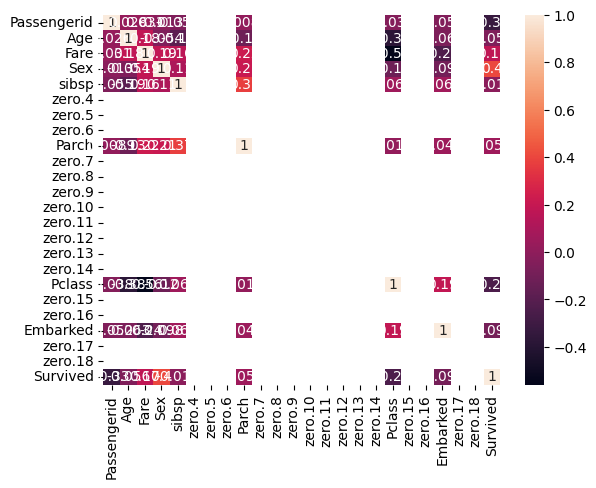

In [81]:
sns.heatmap(df.corr(numeric_only=True),annot=True)


<Axes: xlabel='Survived'>

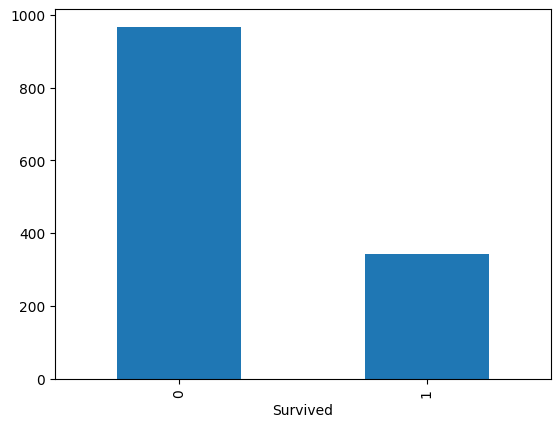

In [84]:
# Compare the number of survived and non-survived passengers
df['Survived'].value_counts().plot(kind='bar')

<Axes: xlabel='Sex'>

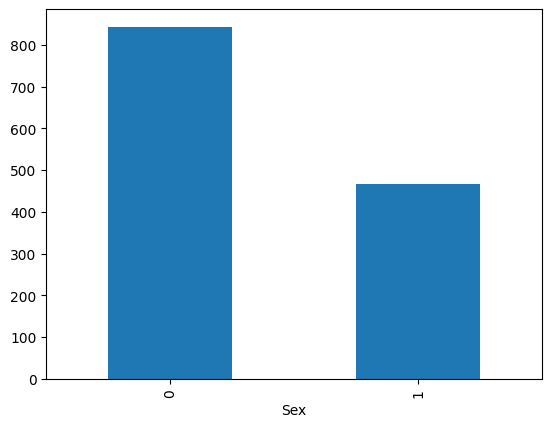

In [86]:
# Compare the number of male and female passengers
df['Sex'].value_counts().plot(kind='bar')

<Axes: xlabel='Pclass'>

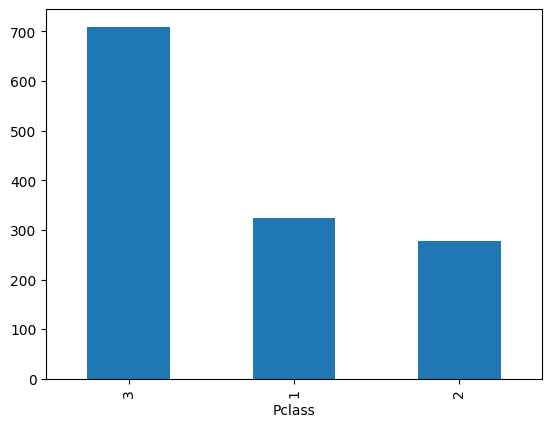

In [87]:
# Compare the number of passengers in each passenger class
df['Pclass'].value_counts().plot(kind='bar')

<Axes: ylabel='Frequency'>

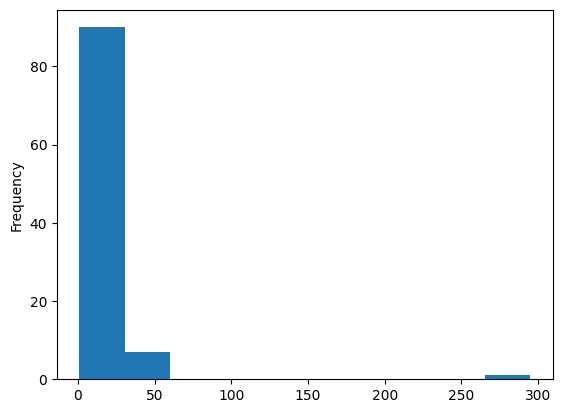

In [89]:
# Visualize the distribution of passenger ages
df.head()
df['Age'].value_counts().plot(kind='hist')

<Axes: ylabel='Frequency'>

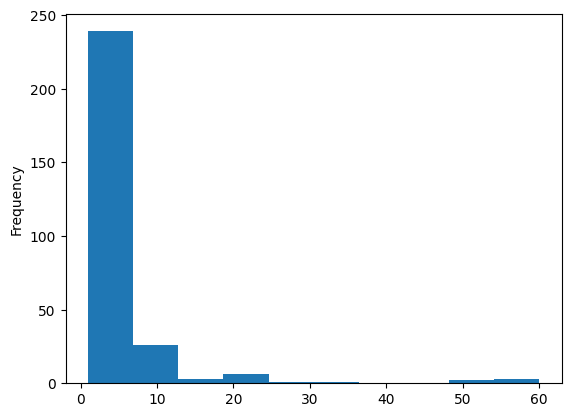

In [92]:
# Visualize the distribution of passenger fares
df['Fare'].value_counts().plot(kind='hist')

<Axes: >

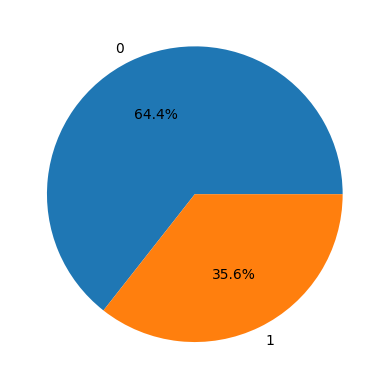

In [94]:
# Visualize the proportion of male and female passengers
df['Sex'].value_counts().plot(kind='pie',autopct='%1.1f%%')

<Axes: >

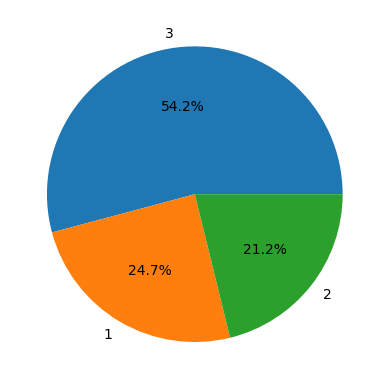

In [97]:
# Visualize the proportion of passengers in each passenger class
df['Pclass'].value_counts().plot(kind='pie',autopct='%1.1f%%')

Text(0.5, 1.0, 'Relationship between Age and Fare')

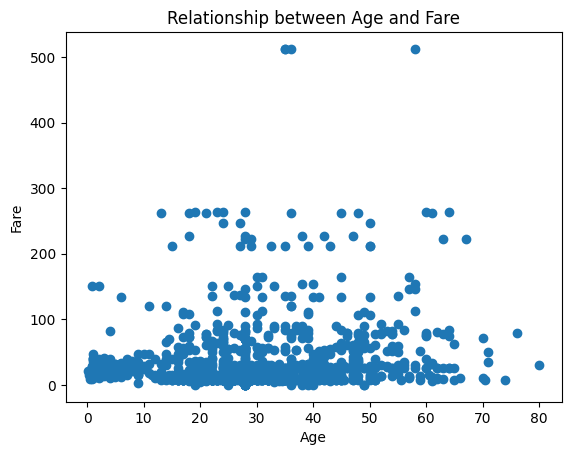

In [103]:
# Visualize the relationship between Age and Fare
plt.scatter(df['Age'],df['Fare'])
plt.xlabel('Age')
plt.ylabel('Fare')
plt.title('Relationship between Age and Fare')

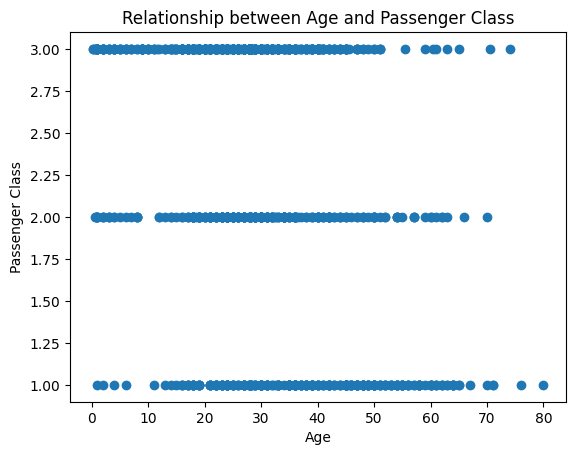

In [102]:
# Visualize the relationship between Age and Passenger Class
plt.scatter(df['Age'],df['Pclass'])
plt.xlabel('Age')
plt.ylabel('Passenger Class')
plt.title('Relationship between Age and Passenger Class')
plt.show()

Text(0.5, 1.0, 'relationship between Fare and Survival')

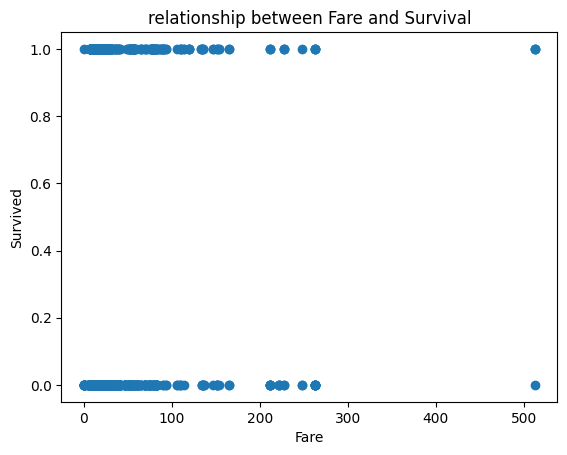

In [104]:
# Visualize the relationship between Fare and Survival
plt.scatter(df['Fare'],df['Survived'])
plt.xlabel('Fare')
plt.ylabel('Survived')
plt.title('relationship between Fare and Survival')

Text(0, 0.5, 'Average Fare')

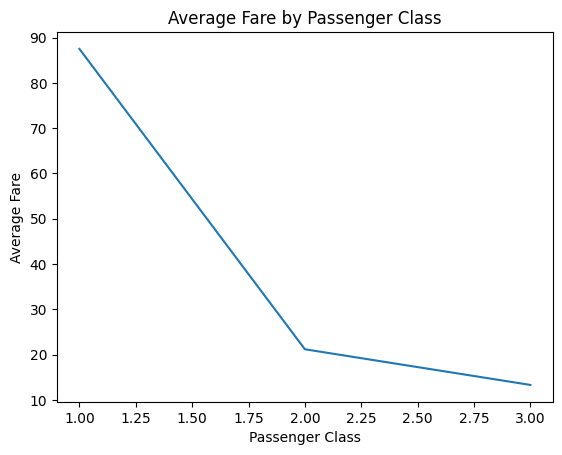

In [108]:
# Plot the average fare for each passenger class
avg_fare=df.groupby('Pclass')['Fare'].mean()
plt.plot(avg_fare.index,avg_fare.values)

plt.title('Average Fare by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Average Fare')


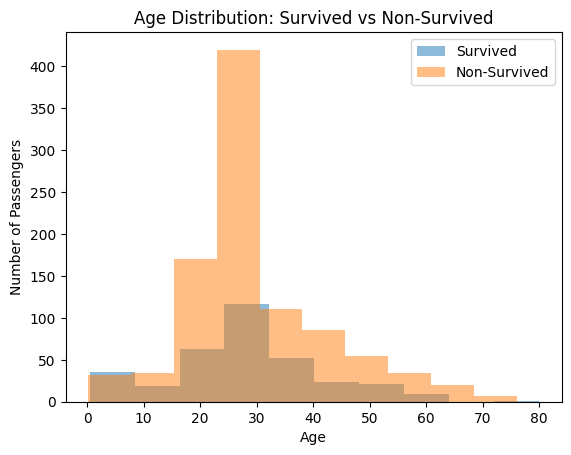

In [110]:
# Compare the age distribution between survived and non-survived passengers
plt.hist(df[df['Survived'] == 1]['Age'], alpha=0.5, label='Survived')
plt.hist(df[df['Survived'] == 0]['Age'], alpha=0.5, label='Non-Survived')

plt.xlabel('Age')
plt.ylabel('Number of Passengers')
plt.title('Age Distribution: Survived vs Non-Survived')
plt.legend()
plt.show()

Text(0.5, 1.0, 'Correlation Between Numerical Columns')

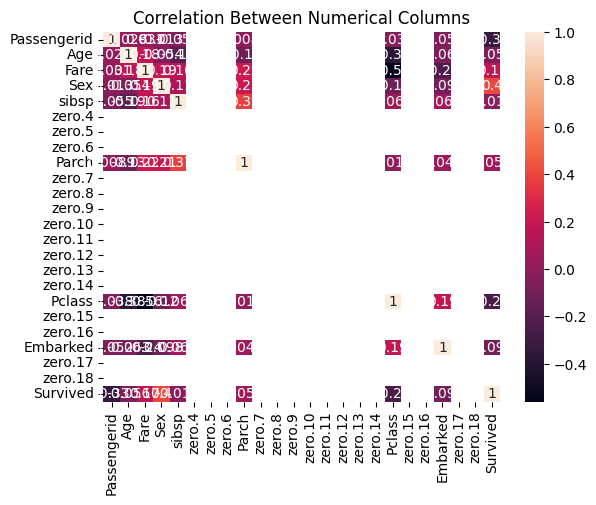

In [113]:
# Compare the age distribution of survived and non-survived passengers
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True)
plt.title('Correlation Between Numerical Columns')

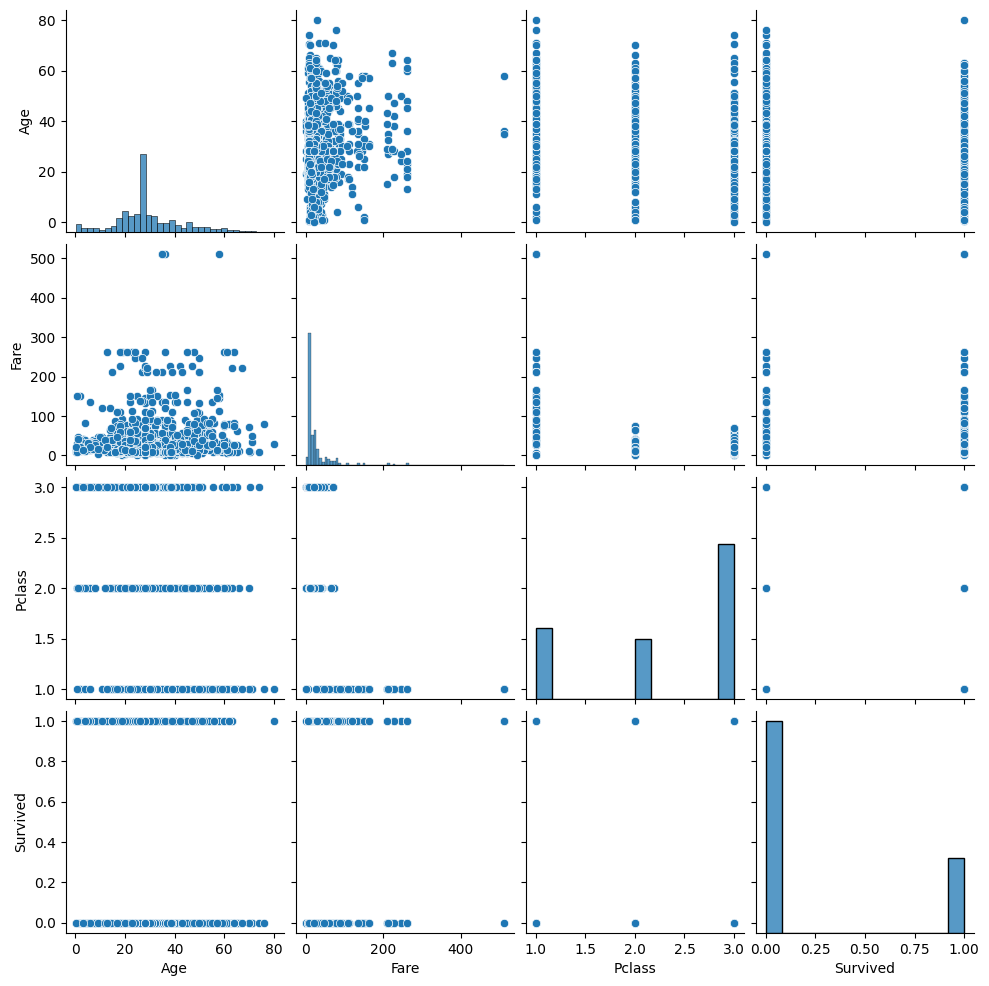

In [ ]:
# Visualize pairwise relationships between Age, Fare, Pclass, and Survived
sns.pairplot(df[['Age', 'Fare', 'Pclass', 'Survived']])
plt.show()

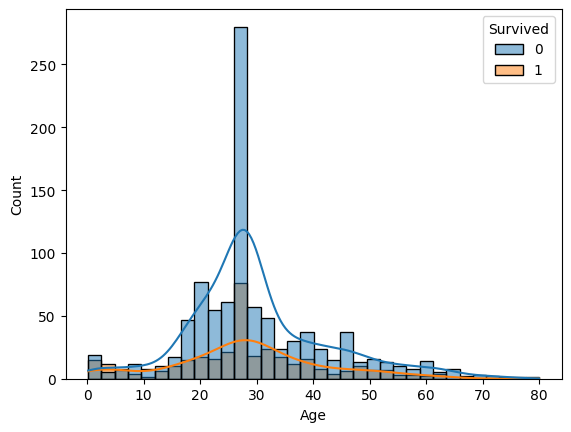

In [115]:
sns.histplot(data=df, x='Age', hue='Survived', kde=True)
plt.show()